# Summary analysis for selection history


- For this to work, you need to adapt the folder where raw data and metaData live.
- Also, you need to clone the jlsocialbehavior repository and create the environment jlsocial from the yml file.

## Define input and output folders. Give metadata location


In [1]:
import os

#define folders

# base = 'Y:\\Johannes\\b\\2019\\' This is the original base folder where the meta data was stored
nasPath='//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/' # adapt this to your own NAS D2c path
metaFolder = '//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/Carlos/shoaling_data/'  # Updated base folder. Metadata should live here.
codeDir = 'C:/Users/crodri19/OneDrive - Université de Lausanne/LarschPostDoc/analyses/selection_shoaling/jlsocialbehavior/' #adapt this to your code folder
metaFile='MetaData_JL_2019_consolidated_v3.xlsx'
ProcessingDir = '//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//shoaling_selection//ShoalHist_temp_processing//'
outputDir = '//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//shoaling_selection//ShoalHist_temp_output//'

print('searching for meta info here: ' + metaFolder)

os.chdir(codeDir)

searching for meta info here: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/Carlos/shoaling_data/


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.stats.api as sms

%config InteractiveShellApp.pylab_import_all = False
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import sys
import fnmatch

import math
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
from pandas import DataFrame, Series
import seaborn as sns
import glob
#import h5py
from datetime import datetime
import PythonMeta as PMA
from matplotlib.ticker import AutoLocator

import functions.matrixUtilities_joh as mu
import functions.notebookHelper as nh
import functions.metaTree as mt

import models.experiment as xp
import models.experiment_set as es
import functions.paperFigureProps as pfp
pfp.paper()

using plot settings for paper plots
standard figure sizes 
 figSq:  (5, 5) 
 figLs:  (5, 3) 
 figPt:  (3, 5)


## Load experiment and animal metadata


In [3]:
info=pd.read_excel(metaFolder+metaFile, sheet_name='AllExp')
ix=(info.stimulusProtocol=='selection')#&(info.date.isin(['2019-08-05','2019-08-06','2019-09-25','2019-10-04']))
info=info[ix].reset_index(drop=True)
info

,date,stimulusProtocol,set,Line,generation,repeat,selected,path,folder,setup,comments,anNr,start,end,rnaSet,Column1
0,2019-07-18,selection,a,TL3,1.0,1.0,0.0,Johannes/b/selection/,20190718_01_35Animals_dn_TlSel3F1,dn,NaN,176:210,176,210,x,NaN
1,2019-07-18,selection,a,TL3,1.0,1.0,0.0,Johannes/b/selection/,20190718_02_35Animals_up_TlSel3F1,up,NaN,211:245,211,245,x,NaN
2,2019-07-19,selection,a,In3,1.0,1.0,0.0,Johannes/b/selection/,20190719_01_35Animals_dn_InSel3F1,dn,NaN,246:280,246,280,x,NaN
3,2019-07-19,selection,a,In3,1.0,1.0,0.0,Johannes/b/selection/,20190719_02_35Animals_up_InSel3F1,up,NaN,281:315,281,315,x,NaN
4,2019-08-05,selection,s,TL3,1.0,2.0,1.0,Johannes/b/selection/,20190805_01_35Animals_dn_TlSel3F1,dn,NaN,316:350,316,350,x,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,2025-07-28,selection,a,TL1,10.0,1.0,0.0,07_Data/Carlos/Behavior/ShoalingSelection/,20250728_01_35Animals_s1_TLSel1F10,s1,Lo fish in this experiment were TL1_Lo 9 outbred,5450:5484,5450,5484,x,NaN
109,2025-07-28,selection,a,TL1,10.0,1.0,0.0,07_Data/Carlos/Behavior/ShoalingSelection/,20250728_02_35Animals_s2_TLSel1F10,s2,Lo fish in this experiment were TL1_Lo 9 outbred,5485:5519,5485,5519,x,NaN
110,2026-03-03,selection,b,TL1,10.0,2.0,1.0,07_Data/Carlos/Behavior/ShoalingSelection/,20260303_01_35Animals_s1_TLSel1F10.1,s1,Lo fish in this experiment were TL1_Lo 9.1 out...,5520:5554,5520,5554,x,NaN
111,2026-03-30,selection,b,TL1,10.0,2.0,1.0,07_Data/Carlos/Behavior/ShoalingSelection/,20260330_01_35Animals_s2_TLSel3F8.1,s2,NaN,5555:5589,5555,5589,x,NaN


In [4]:
infoAn=pd.read_excel(metaFolder+metaFile, sheet_name='AllAn',parse_dates=['bd'])
infoAn['bd'] = pd.to_datetime(infoAn['bd'], format='%Y%m%d')
#infoAn['expDate'] = pd.to_datetime(infoAn['expDate'], format='%Y%m%d')
infoAn.tail()

C:\Users\crodri19\AppData\Local\Temp\ipykernel_20556\1061432783.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  infoAn=pd.read_excel(metaFolder+metaFile, sheet_name='AllAn',parse_dates=['bd'])


,anNr,line,bg,cohort,generation,repeat,genotype,bd,listBD,year,month,day,sex,conc,Unnamed: 14,Unnamed: 15
5619,5620,TLSel1_10,TL,1,10,3,esc_hi,2026-03-12 09:00:00+00:00,2026-03-19,2026,3,19,NaN,2026-3-19-09-00,NaN,NaN
5620,5621,TLSel1_10,TL,1,10,3,lo,2026-03-12 09:00:00+00:00,2026-03-19,2026,3,19,NaN,2026-3-19-09-00,NaN,NaN
5621,5622,TLSel1_10,TL,1,10,3,esc_hi,2026-03-12 09:00:00+00:00,2026-03-19,2026,3,19,NaN,2026-3-19-09-00,NaN,NaN
5622,5623,TLSel1_10,TL,1,10,3,lo,2026-03-12 09:00:00+00:00,2026-03-19,2026,3,19,NaN,2026-3-19-09-00,NaN,NaN
5623,5624,TLSel1_10,TL,1,10,3,esc_hi,2026-03-12 09:00:00+00:00,2026-03-19,2026,3,19,NaN,2026-3-19-09-00,NaN,NaN


In [5]:
infoAn.genotype.unique()

array(['nd', 'hi', 'lo', 'wt', 'cross', 'h', 'm', 'inx', 'a', 'x', 'dark',
       'light', 'mid', 'cont', 'bout', 'invi', 'fish', 'wp', 'mn', 'wn',
       'mp', 'hp', 'abl', 'ctr', 'none', 'e', 'p', 'n', 'no', 'o', '3n',
       '4n', '3p', '4p', '1e', 'mres', 'da', 'hres', 'li', 'mlres',
       'wres', '1n', '2n', '2p', '1p', 'w', 'ep', 1, 2, 3, 4, 6, 5,
       'todo', 'esc_lo', 'esc_hi'], dtype=object)

## Prepare processing settings


In [6]:
# collect meta information and save to new csv file for batch processing

aviPath=[]
posPath=[]
PLPath=[]
expTime = []
birthDayAll=[]
anIDsAll=[]
camHeightAll=[]

camHeight=[105,180] # these are outdated values, but we keep them for compatibility with old data


for index,row in info.iterrows():

    startDir=nasPath+row.path+row.folder+'\\' # I removed the nas path from the metadata to make this easier to adapt to different computers
    print('processing: ' + startDir)
    if not os.path.exists(startDir):
        print('WARNING: path does not exist: ' + startDir)
        continue

    
    posPath.append(glob.glob(startDir+'PositionTxt*')[0]) #this is the trajectory file
    PLPath.append(glob.glob(startDir+'PL*')[0]) # this is the pair list file
    
    head, tail = os.path.split(posPath[-1])
    currTime='dummy' #datetime.strptime(tail[-23:-4], '%Y-%m-%dT%H_%M_%S')
    expTime.append(currTime)
    
    camHeightAll.append(camHeight[('_dn_' in head)*1]) ######### this needs to be adapted for new data, since the camHeight is not stored in the meta data anymore.
    
    anNrs=row.anNr #Note that anNrs are 1 based!
    if ':' in anNrs:
        a,b=anNrs.split(sep=':')
        anNrs=np.arange(int(a),int(b)+1)
    else:
        anNrs=np.array(anNrs.split()).astype(int)
        
    anIDs=anNrs #-1 no more 0-based since using pandas merge to find animal numbers
    anIDsAll.extend(anIDs)

    bd=infoAn[infoAn.anNr.isin(anIDs)].bd.values.astype(str) # get birth dates of animals in this experiment
    #bd=infoAn.bd.values[anIDs-1] #a bit dirty to use anIDs directly here. Should merge
    birthDayAll.append(' '.join(list(bd)))

info['camHeight']=camHeightAll
info['txtPath']=posPath
info['pairList']=PLPath
info['aviPath']='default'
info['birthDayAll']=birthDayAll
info['epiDur'] = 5      # duration of individual episodes (default: 5 minutes)
info['episodes'] = 24   # number of episodes to process: -1 to load all episodes (default: -1)
info['inDish'] = 10#np.arange(len(posPath))*120     # time in dish before experiments started (default: 10)
info['arenaDiameter_mm'] = 70 # arena diameter (default: 100 mm)
info['minShift'] = 60 # minimum number of seconds to shift for control IAD
info['episodePLcode'] = 0 # flag if first two characters of episode name encode animal pair matrix (default: 0)
info['recomputeAnimalSize'] = 0 # flag to compute animals size from avi file (takes time, default: 1)
info['SaveNeighborhoodMaps'] = 0 # flag to save neighborhood maps for subsequent analysis (takes time, default: 1)
info['computeLeadership'] = 0 # flag to compute leadership index (takes time, default: 1)
info['ComputeBouts'] = 1 # flag to compute swim bout frequency (takes time, default: 1)
#info['set'] = np.arange(len(posPath))   # experiment set: can label groups of experiments (default: 0)
info['ProcessingDir']=ProcessingDir
info['outputDir']=outputDir
info['expTime']=expTime
info['readLim'] = 24*5*60*30+11

processing: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/Johannes/b/selection/20190718_01_35Animals_dn_TlSel3F1\
processing: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/Johannes/b/selection/20190718_02_35Animals_up_TlSel3F1\
processing: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/Johannes/b/selection/20190719_01_35Animals_dn_InSel3F1\
processing: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/Johannes/b/selection/20190719_02_35Animals_up_InSel3F1\
processing: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/Johannes/b/selection/20190805_01_35Animals_dn_TlSel3F1\
processing: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/Johannes/b/selection/20190805_02_35Animals_up_TlSel3F1\
processing: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/Johannes/b/selection/20190806_01_35Animals_dn_InSel3F1\
processing: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/Johannes/b/selection/20190806_02

In [7]:
csvFile=os.path.join(ProcessingDir,'processingSettings.csv')
info.to_csv(csvFile,encoding='utf-8')
info.tail()


,date,stimulusProtocol,set,Line,generation,repeat,selected,path,folder,setup,...,minShift,episodePLcode,recomputeAnimalSize,SaveNeighborhoodMaps,computeLeadership,ComputeBouts,ProcessingDir,outputDir,expTime,readLim
108,2025-07-28,selection,a,TL1,10.0,1.0,0.0,07_Data/Carlos/Behavior/ShoalingSelection/,20250728_01_35Animals_s1_TLSel1F10,s1,...,60,0,0,0,0,1,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,dummy,216011
109,2025-07-28,selection,a,TL1,10.0,1.0,0.0,07_Data/Carlos/Behavior/ShoalingSelection/,20250728_02_35Animals_s2_TLSel1F10,s2,...,60,0,0,0,0,1,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,dummy,216011
110,2026-03-03,selection,b,TL1,10.0,2.0,1.0,07_Data/Carlos/Behavior/ShoalingSelection/,20260303_01_35Animals_s1_TLSel1F10.1,s1,...,60,0,0,0,0,1,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,dummy,216011
111,2026-03-30,selection,b,TL1,10.0,2.0,1.0,07_Data/Carlos/Behavior/ShoalingSelection/,20260330_01_35Animals_s2_TLSel3F8.1,s2,...,60,0,0,0,0,1,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,dummy,216011
112,2026-04-07,selection,c,TL3,8.0,3.0,1.0,07_Data/Carlos/Behavior/ShoalingSelection/,20260407_01_35Animals_s2_TLSel1F10.1,s2,...,60,0,0,0,0,1,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,dummy,216011


## Read experiment data and processed shoaling summaries


In [8]:
rereadData=1
if rereadData:
    def readExperiment(keepData=True):
        tmp=es.experiment_set(csvFile=csvFile,MissingOnly=True)
        if keepData:
            return tmp
        else:
            return 1

    expSet=readExperiment(keepData=False)

False False //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//shoaling_selection//ShoalHist_temp_processing//PositionTxt_allROI2019-07-18T11_10_59*siSummary*.csv
False False //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//shoaling_selection//ShoalHist_temp_processing//PositionTxt_allROI2019-07-18T11_36_23*siSummary*.csv
False False //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//shoaling_selection//ShoalHist_temp_processing//PositionTxt_allROI2019-07-19T10_46_57*siSummary*.csv
False False //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//shoaling_selection//ShoalHist_temp_processing//PositionTxt_allROI2019-07-19T11_04_05*siSummary*.csv
False False //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//shoaling_selection//ShoalHist_temp_processing//PositionTxt_allROI2019-08-05T11_10_03*siSummary*.csv
False False //nasdcsr.unil.ch/RECHE

In [9]:
csvPath = []
for f in [mu.splitall(x)[-1][:-4] for x in info.txtPath]:
    csvPath.append(glob.glob(ProcessingDir+f+'*siSummary*.csv')[0])

df=pd.DataFrame()
i=0
for fn in csvPath:
    print(fn)
    tmp=pd.read_csv(fn,index_col=0,sep=',')
    tmp.animalSet=i
    tmp.animalIndex=tmp.animalIndex+((i)*35)
    tmp.animalIndex=np.array(anIDsAll)[tmp.animalIndex]
    df=pd.concat([df,tmp])
    i+=1

df.tail(10)



//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//shoaling_selection//ShoalHist_temp_processing\PositionTxt_allROI2019-07-18T11_10_59_siSummary_epi5.0.csv
//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//shoaling_selection//ShoalHist_temp_processing\PositionTxt_allROI2019-07-18T11_36_23_siSummary_epi5.0.csv
//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//shoaling_selection//ShoalHist_temp_processing\PositionTxt_allROI2019-07-19T10_46_57_siSummary_epi5.0.csv
//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//shoaling_selection//ShoalHist_temp_processing\PositionTxt_allROI2019-07-19T11_04_05_siSummary_epi5.0.csv
//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//shoaling_selection//ShoalHist_temp_processing\PositionTxt_allROI2019-08-05T11_10_03_siSummary_epi5.0.csv
//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_

,animalSet,animalIndex,animalID,CurrentPartner,si,episode,epStart,inDishTime,epiNr,time,...,stimulusProtocol,age,avgSpeed,avgSpeed_smooth,anSize,thigmoIndex,boutDur,leadershipIndex,sync_amp,sync_t
830,112,5615,25,35,0.062695,02k20f,207000,125.0,23,125.0,...,selection,0.0,8.917628,8.024999,0.0,17.803978,0.666667,0,0.0,0.0
831,112,5616,26,35,0.377288,02k20f,207000,125.0,23,125.0,...,selection,0.0,6.350832,5.178834,0.0,16.443600,0.800000,0,0.0,0.0
832,112,5617,27,35,0.015521,02k20f,207000,125.0,23,125.0,...,selection,0.0,10.066521,8.547347,0.0,17.486834,0.633333,0,0.0,0.0
833,112,5618,28,35,0.245765,02k20f,207000,125.0,23,125.0,...,selection,0.0,8.292571,6.770152,0.0,16.404730,0.733333,0,0.0,0.0
834,112,5619,29,35,0.141180,02k20f,207000,125.0,23,125.0,...,selection,0.0,5.497532,4.575762,0.0,14.100454,0.866667,0,0.0,0.0
835,112,5620,30,35,0.267188,02k20f,207000,125.0,23,125.0,...,selection,0.0,6.116588,5.154243,0.0,13.670095,0.900000,0,0.0,0.0
836,112,5621,31,35,0.171219,02k20f,207000,125.0,23,125.0,...,selection,0.0,5.404116,4.169318,0.0,15.061904,1.016667,0,0.0,0.0
837,112,5622,32,35,0.308514,02k20f,207000,125.0,23,125.0,...,selection,0.0,7.842720,7.039462,0.0,15.510239,0.700000,0,0.0,0.0
838,112,5623,33,35,0.058338,02k20f,207000,125.0,23,125.0,...,selection,0.0,15.079854,10.083326,0.0,22.977541,0.666667,0,0.0,0.0
839,112,5624,34,35,0.298053,02k20f,207000,125.0,23,125.0,...,selection,0.0,6.067455,5.138082,0.0,14.111107,0.800000,0,0.0,0.0


In [10]:

df['episode']=[x.strip().replace('_','') for x in df['episode']]
df=pd.merge(df,infoAn[['anNr','line','genotype','bg','cohort','generation','repeat']],left_on='animalIndex',right_on='anNr',how='left')
df=pd.merge(df,info[['date','selected','set','setup','rnaSet']],left_on='animalSet',right_on=info.index,how='left')
df['setup'] = info['setup'].values[df['animalSet'].values]
print('df shape',df.shape)
df['lineSet']=[x+'_'+y for x,y in zip(df.line, df.date)]


df.tail(10)



df shape (113085, 33)


,animalSet,animalIndex,animalID,CurrentPartner,si,episode,epStart,inDishTime,epiNr,time,...,bg,cohort,generation,repeat,date,selected,set,setup,rnaSet,lineSet
113075,112,5615,25,35,0.062695,02k20f,207000,125.0,23,125.0,...,TL,1,10,3,2026-04-07,1.0,c,s2,x,TLSel1_10_2026-04-07
113076,112,5616,26,35,0.377288,02k20f,207000,125.0,23,125.0,...,TL,1,10,3,2026-04-07,1.0,c,s2,x,TLSel1_10_2026-04-07
113077,112,5617,27,35,0.015521,02k20f,207000,125.0,23,125.0,...,TL,1,10,3,2026-04-07,1.0,c,s2,x,TLSel1_10_2026-04-07
113078,112,5618,28,35,0.245765,02k20f,207000,125.0,23,125.0,...,TL,1,10,3,2026-04-07,1.0,c,s2,x,TLSel1_10_2026-04-07
113079,112,5619,29,35,0.141180,02k20f,207000,125.0,23,125.0,...,TL,1,10,3,2026-04-07,1.0,c,s2,x,TLSel1_10_2026-04-07
113080,112,5620,30,35,0.267188,02k20f,207000,125.0,23,125.0,...,TL,1,10,3,2026-04-07,1.0,c,s2,x,TLSel1_10_2026-04-07
113081,112,5621,31,35,0.171219,02k20f,207000,125.0,23,125.0,...,TL,1,10,3,2026-04-07,1.0,c,s2,x,TLSel1_10_2026-04-07
113082,112,5622,32,35,0.308514,02k20f,207000,125.0,23,125.0,...,TL,1,10,3,2026-04-07,1.0,c,s2,x,TLSel1_10_2026-04-07
113083,112,5623,33,35,0.058338,02k20f,207000,125.0,23,125.0,...,TL,1,10,3,2026-04-07,1.0,c,s2,x,TLSel1_10_2026-04-07
113084,112,5624,34,35,0.298053,02k20f,207000,125.0,23,125.0,...,TL,1,10,3,2026-04-07,1.0,c,s2,x,TLSel1_10_2026-04-07


In [11]:
df.lineSet.unique()

array(['TLSel3_2019-07-18', 'InSel3_2019-07-19', 'TLSel3_2019-08-05',
       'InSel3_2019-08-06', 'TLSel1_2019-09-25', 'InSel2_2019-10-04',
       'EkSel3_2019-10-04', 'wt_TL1_2019-02-26', 'wt_In1_2019-02-26',
       'wt_EK1_2019-02-26', 'wt_EK1_2019-03-01', 'wt_TL1_2019-03-01',
       'wt_In1_2019-03-01', 'wt_In2_2019-03-18', 'wt_EK2_2019-03-18',
       'wt_TL2_2019-03-18', 'wt_TL2_2019-03-21', 'wt_In2_2019-03-21',
       'wt_EK2_2019-03-21', 'wt_In3_2019-04-26', 'wt_TL3_2019-04-26',
       'wt_EK3_2019-04-26', 'wt_TL3_2019-04-29', 'wt_In3_2019-04-29',
       'wt_EK3_2019-04-29', 'TLSel3_2_2019-10-30', 'TLSel3_2019-10-31',
       'TLSel3_2_2019-11-02', 'InSel3_2_2019-11-03',
       'TL3Lo2xIn3Hi2_2019-11-11', 'TLSel3_2_2019-11-11',
       'TL3Lo2xIn3Lo2_2019-11-11', 'InSel3_2_2019-11-11',
       'TL3Hi2xIn3Hi2_2019-11-11', 'TLSel3_2_2019-11-12',
       'TL3Hi2xIn3Hi2_2019-11-12', 'InSel3_2_2019-11-12',
       'TL3Lo2xIn3Lo2_2019-11-12', 'TL3Hi23xTL3Lo23_2019-12-09',
       'TL3Lo21xTL

## Build episode-level animal summaries


In [12]:
sns.set_palette('viridis',3)
co=sns.color_palette("viridis", 3)
idx=(df['inDishTime']<240) & (df['inDishTime']>80)
dfDR=df[idx]
dfEpiAn=dfDR.groupby(['episode','animalIndex','line','setup','genotype','date','lineSet','bg','cohort','generation','repeat','set','rnaSet'],sort=True).mean(numeric_only=True).reset_index()

In [13]:
dfEpiAn.head()

dfEpiAn.lineSet.unique()

array(['TLSel3_2019-07-18', 'InSel3_2019-07-19', 'TLSel3_2019-08-05',
       'InSel3_2019-08-06', 'TLSel1_2019-09-25', 'InSel2_2019-10-04',
       'EkSel3_2019-10-04', 'wt_TL1_2019-02-26', 'wt_TL1_2019-03-01',
       'wt_In1_2019-02-26', 'wt_In1_2019-03-01', 'wt_EK1_2019-02-26',
       'wt_EK1_2019-03-01', 'wt_In2_2019-03-18', 'wt_In2_2019-03-21',
       'wt_EK2_2019-03-18', 'wt_EK2_2019-03-21', 'wt_TL2_2019-03-18',
       'wt_TL2_2019-03-21', 'wt_In3_2019-04-26', 'wt_In3_2019-04-29',
       'wt_TL3_2019-04-26', 'wt_TL3_2019-04-29', 'wt_EK3_2019-04-26',
       'wt_EK3_2019-04-29', 'TLSel3_2_2019-10-30', 'TLSel3_2_2019-11-02',
       'TLSel3_2019-10-31', 'InSel3_2_2019-11-03',
       'TL3Lo2xIn3Hi2_2019-11-11', 'TLSel3_2_2019-11-11',
       'TL3Lo2xIn3Lo2_2019-11-11', 'InSel3_2_2019-11-11',
       'TL3Hi2xIn3Hi2_2019-11-11', 'TLSel3_2_2019-11-12',
       'TL3Hi2xIn3Hi2_2019-11-12', 'InSel3_2_2019-11-12',
       'TL3Lo2xIn3Lo2_2019-11-12', 'TL3Hi23xTL3Lo23_2019-12-09',
       'TL3Lo21xTL

## Summary statistic helpers


In [14]:

def sem(x):
    return np.std(x, ddof=1) / np.sqrt(len(x))

x=np.random.random(100)

def ci95(x):
    return np.nanmean(x)-sms.DescrStatsW(x[np.isfinite(x)]).tconfint_mean()[0]

print('std of uniform = 0.2886751345948129. STDdata:',np.std(x), 'semData:',sem(x),'samples:',x.shape) 
print('ci95:',ci95(x))

std of uniform = 0.2886751345948129. STDdata: 0.29264628145864063 semData: 0.029412057936092466 samples: (100,)
ci95: 0.05835990393555013


In [15]:
dfPlot=(df.groupby(['inDishTime','episode','genotype','lineSet']).si.agg(['mean','std',sem,ci95])
    .unstack()
    .stack(dropna=True)
    .reset_index())

dfPlot.lineSet.unique()

df.lineSet.unique()

c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\statsmodels\stats\weightstats.py:228: RuntimeWarning: invalid value encountered in scalar divide
  return std / np.sqrt(self.sum_weights - 1)
C:\Users\crodri19\AppData\Local\Temp\ipykernel_20556\2898514957.py:3: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=True)


array(['TLSel3_2019-07-18', 'InSel3_2019-07-19', 'TLSel3_2019-08-05',
       'InSel3_2019-08-06', 'TLSel1_2019-09-25', 'InSel2_2019-10-04',
       'EkSel3_2019-10-04', 'wt_TL1_2019-02-26', 'wt_In1_2019-02-26',
       'wt_EK1_2019-02-26', 'wt_EK1_2019-03-01', 'wt_TL1_2019-03-01',
       'wt_In1_2019-03-01', 'wt_In2_2019-03-18', 'wt_EK2_2019-03-18',
       'wt_TL2_2019-03-18', 'wt_TL2_2019-03-21', 'wt_In2_2019-03-21',
       'wt_EK2_2019-03-21', 'wt_In3_2019-04-26', 'wt_TL3_2019-04-26',
       'wt_EK3_2019-04-26', 'wt_TL3_2019-04-29', 'wt_In3_2019-04-29',
       'wt_EK3_2019-04-29', 'TLSel3_2_2019-10-30', 'TLSel3_2019-10-31',
       'TLSel3_2_2019-11-02', 'InSel3_2_2019-11-03',
       'TL3Lo2xIn3Hi2_2019-11-11', 'TLSel3_2_2019-11-11',
       'TL3Lo2xIn3Lo2_2019-11-11', 'InSel3_2_2019-11-11',
       'TL3Hi2xIn3Hi2_2019-11-11', 'TLSel3_2_2019-11-12',
       'TL3Hi2xIn3Hi2_2019-11-12', 'InSel3_2_2019-11-12',
       'TL3Lo2xIn3Lo2_2019-11-12', 'TL3Hi23xTL3Lo23_2019-12-09',
       'TL3Lo21xTL

## Shoaling index analyses


### Shoaling index across selection history


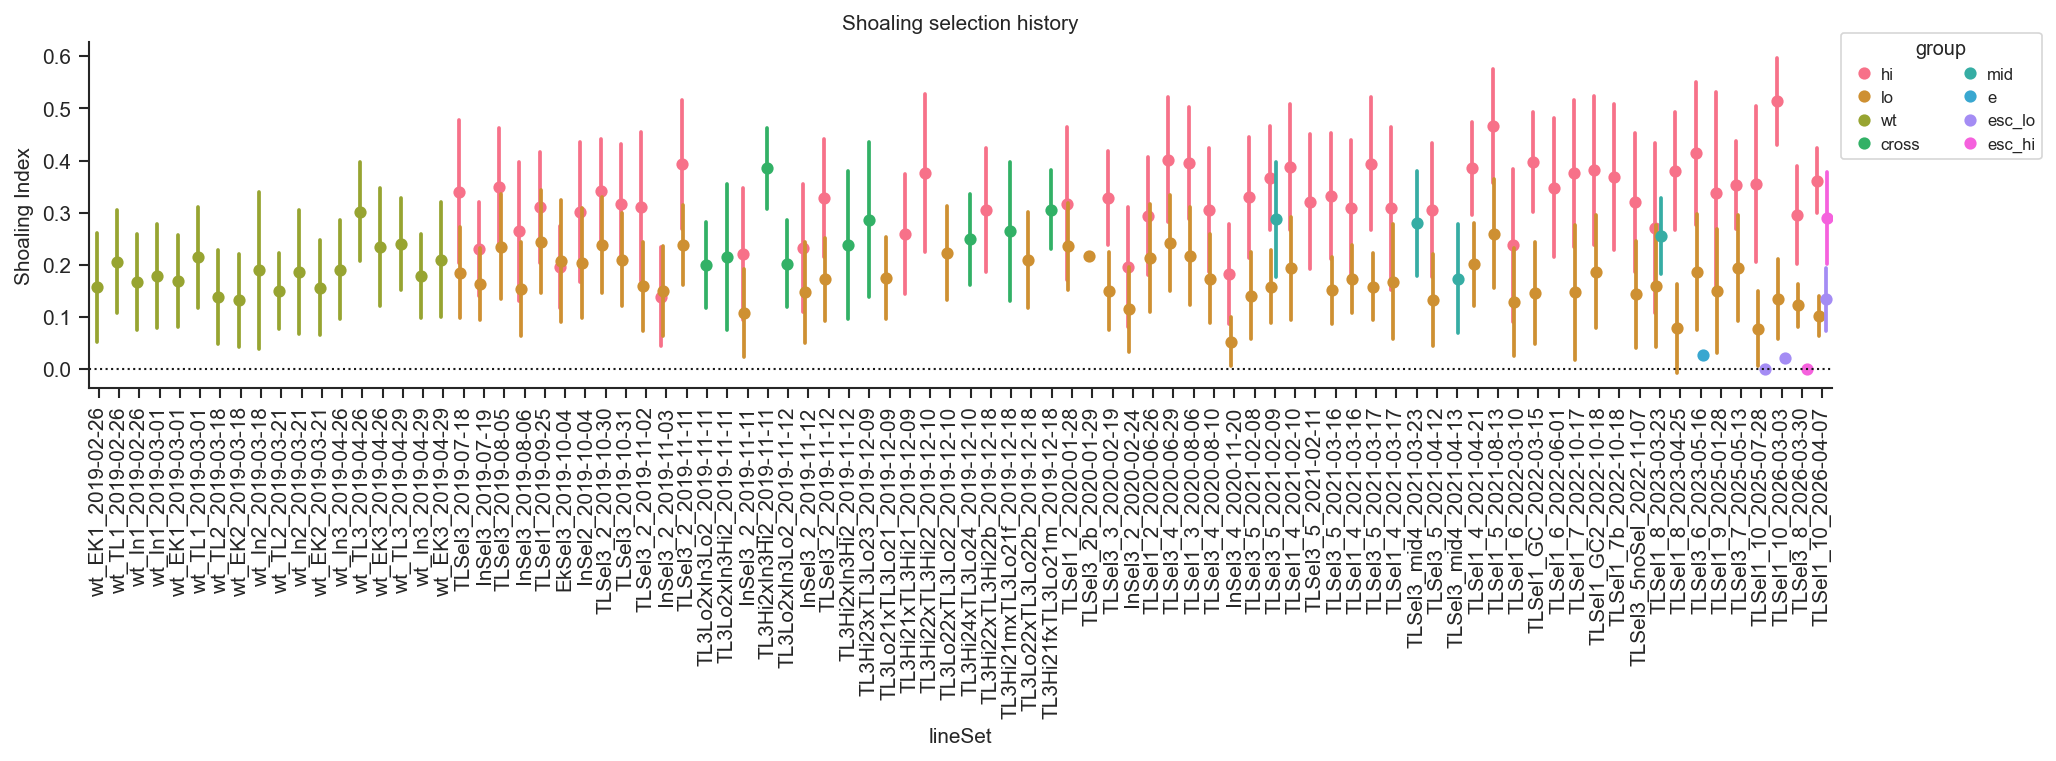

In [16]:
order = dfEpiAn[dfEpiAn.episode=='02k20f'].groupby('lineSet')['date'].first().sort_values().index.tolist()

fig, axes = plt.subplots(figsize=(15,3))

sns.pointplot(data=dfEpiAn[dfEpiAn.episode=='02k20f'],
              x='lineSet',
              y='si',
              order = order,
              hue='genotype',
              
             linestyle='none',
             errorbar='sd',
             dodge=.5)
sns.despine()

axes.set_ylabel('Shoaling Index')
axes.axhline(0,ls=':',color='k')
axes.set_title('Shoaling selection history');
plt.legend(title='group',ncol=2,handletextpad=0,bbox_to_anchor=(1, 1.05))
plt.xticks(rotation=90);

### Selection history swarm plots


c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 9.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 11.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 8.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 5.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.wa

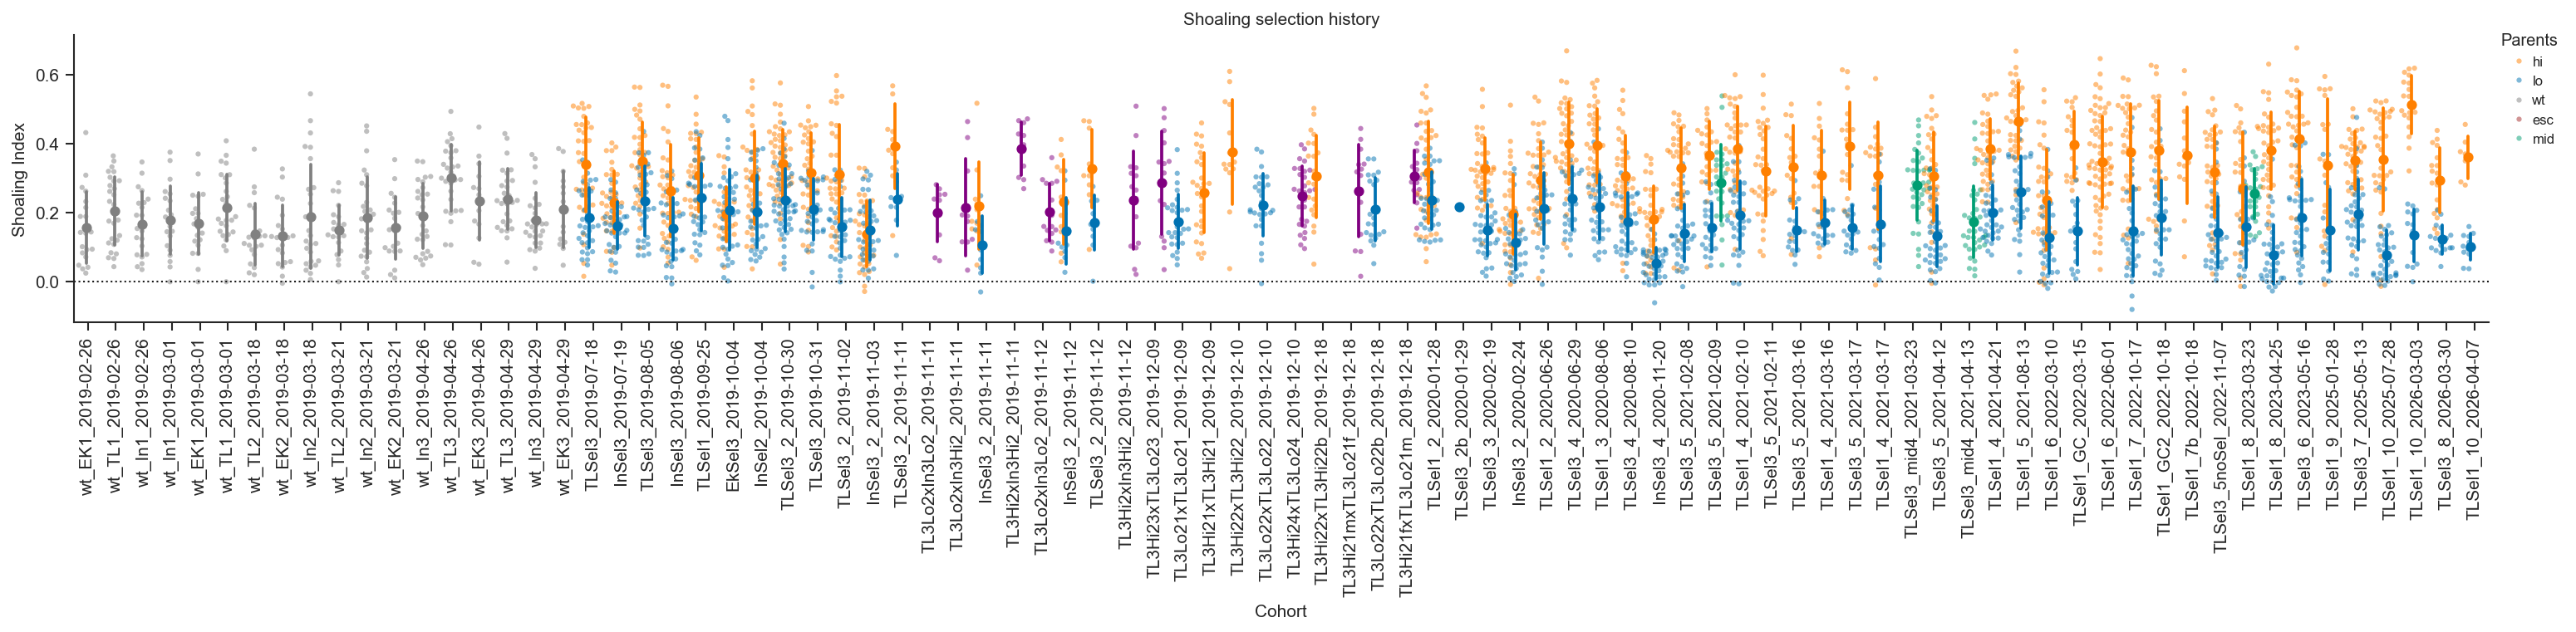

In [17]:
order = dfEpiAn[dfEpiAn.episode=='02k20f'].groupby('lineSet')['date'].first().sort_values().index.tolist()

fig, axes = plt.subplots(figsize=(25, 3))
ix=(dfEpiAn.episode=='02k20f')#&(~dfEpiAn.lineSet.str.contains('_2_'))

selDat=dfEpiAn[ix]

allCat=selDat.lineSet.unique()
allCat.sort()
allCat=allCat[::-1]

sns.swarmplot(data=selDat,
              x='lineSet',
              y='si',
              hue='genotype',
              order=order,
              zorder=-1,
              dodge=.5,
              size=3,
              alpha=.5,
              #order=allCat,
              palette={'hi': '#FF8000', 'lo': '#0072B2', 'mid': '#009E73', 'wt': 'gray', 'esc': 'brown', 'cross': 'purple'},
              hue_order=["hi", "lo",'wt','esc','mid','cross'])

sns.pointplot(data=selDat,
              x='lineSet',
              y='si',
              order=order,
              hue='genotype',
              dodge=.5,
              linestyle='none',
              errorbar='sd',
              palette={'hi': '#FF8000', 'lo': '#0072B2', 'mid': '#009E73', 'wt': 'gray', 'esc': 'brown', 'cross': 'purple'},
              hue_order=["hi", "lo",'wt','esc','mid','cross'])


sns.despine()

axes.set_ylabel('Shoaling Index')
axes.set_xlabel('Cohort')

axes.axhline(0,ls=':',color='k')
#axes.set_title('Selection F1');

plt.xticks(rotation=90);

handles, labels = axes.get_legend_handles_labels()

l = plt.legend(handles[0:5], labels[0:5], title='Parents',ncol=1,handletextpad=0,
               bbox_to_anchor=(1, 1.05),
              frameon=False)

#figPath=base+'SelectionAllToF1.png'
#plt.savefig(figPath,bbox_inches='tight')

plt.title('Shoaling selection history');


### Selection history ordered by background and generation


c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 9.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 8.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 11.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 22.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.w

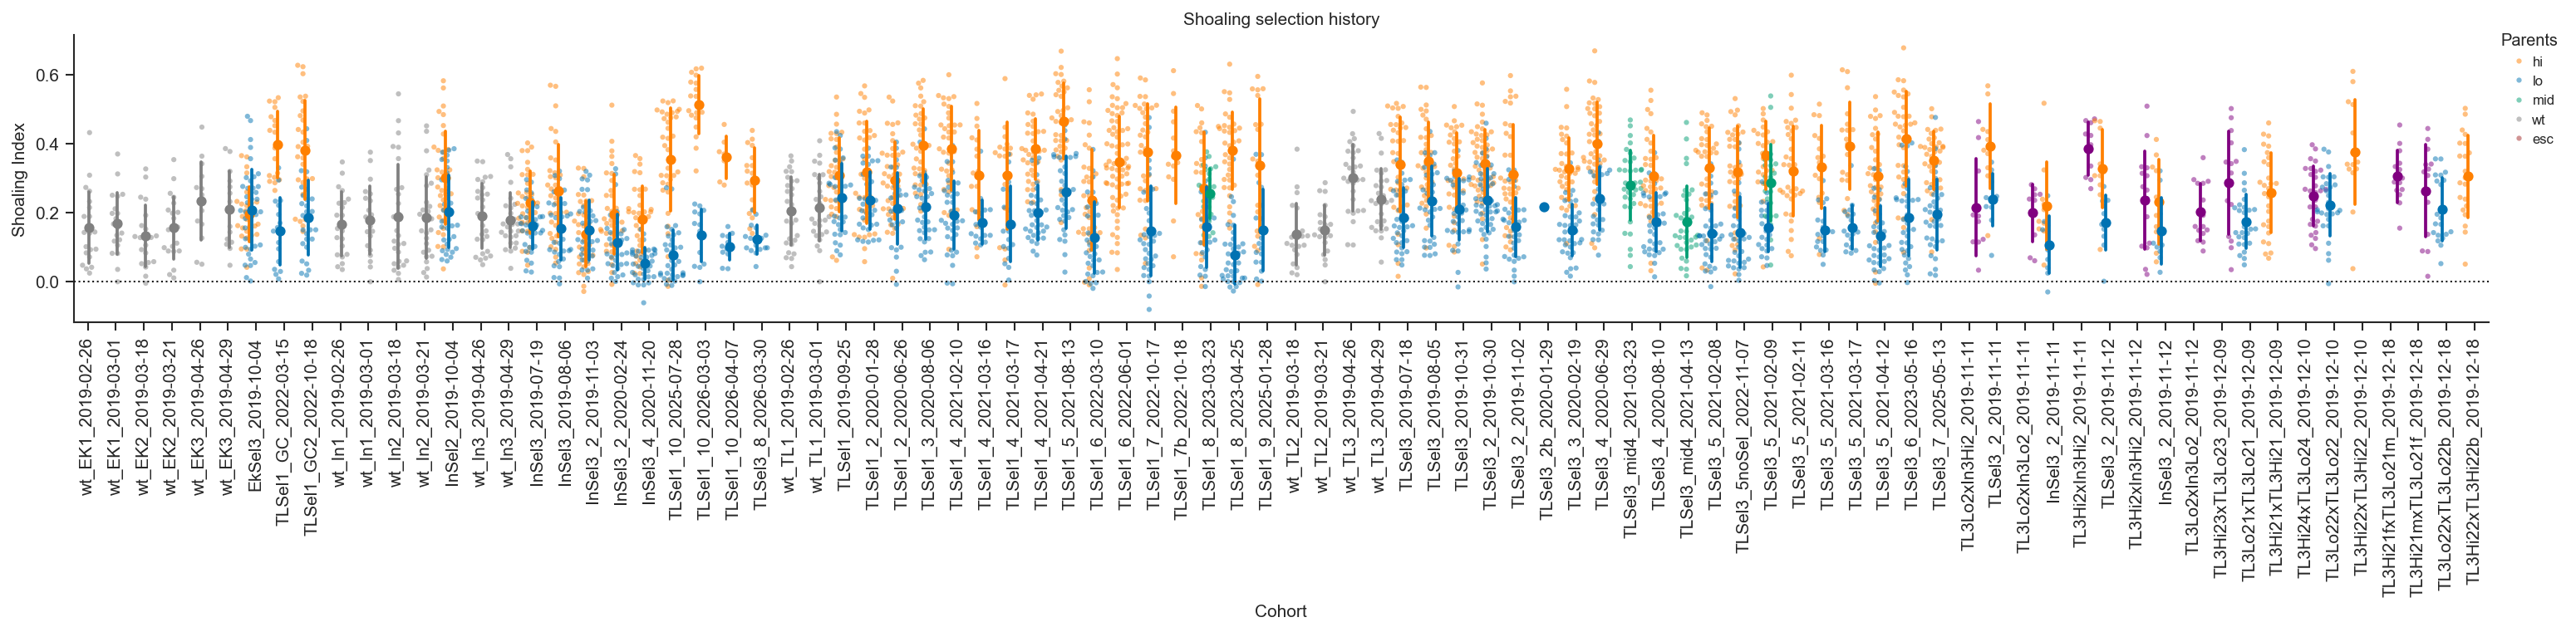

In [18]:

fig, axes = plt.subplots(figsize=(25, 3))
ix=(dfEpiAn.episode=='02k20f')
selDat=dfEpiAn[ix]


order = selDat.sort_values(['bg', 'cohort', 'generation', 'repeat'])['lineSet'].unique().tolist()
allCat=selDat.lineSet.unique()
allCat.sort()
allCat=allCat[::-1]

sns.swarmplot(data=selDat,
              x='lineSet',
              y='si',
              hue='genotype',
              order=order,
              zorder=-1,
              dodge=.5,
              size=3,
              alpha=.5,
              #order=allCat,
              palette={'hi': '#FF8000', 'lo': '#0072B2', 'mid': '#009E73', 'wt': 'gray', 'esc': 'brown', 'cross': 'purple'},
              hue_order=["hi", "lo", 'mid', 'wt','esc','cross'])

sns.pointplot(data=selDat,
              x='lineSet',
              y='si',
              order=order,
              hue='genotype',
              dodge=.5,
              linestyle='none',
              errorbar='sd',
              palette={'hi': '#FF8000', 'lo': '#0072B2', 'mid': '#009E73', 'wt': 'gray', 'esc': 'brown', 'cross': 'purple'},
              hue_order=["hi", "lo", 'mid', 'wt', 'esc', 'cross'])


sns.despine()

axes.set_ylabel('Shoaling Index')
axes.set_xlabel('Cohort')

axes.axhline(0,ls=':',color='k')
#axes.set_title('Selection F1');

plt.xticks(rotation=90);

handles, labels = axes.get_legend_handles_labels()

l = plt.legend(handles[0:5], labels[0:5], title='Parents',ncol=1,handletextpad=0,
               bbox_to_anchor=(1, 1.05),
              frameon=False)

#figPath=base+'SelectionAllToF1.png'
#plt.savefig(figPath,bbox_inches='tight')

plt.title('Shoaling selection history');


### Filter incomplete historical experiments


In [19]:
print(dfEpiAn)

# Normalize cohort to string so plotting filters with string cohort values remain consistent.
dfEpiAn['cohort'] = dfEpiAn['cohort'].astype(str)

#Filter used to removed incomplete data points for poster presentation of Genopode 2025 retreat. 
#prefiltered_dfEpiAn = dfEpiAn[~dfEpiAn['date'].isin(['2022-06-01', '2022-10-18', '2020-01-29'])]
prefiltered_dfEpiAn = dfEpiAn[~dfEpiAn['date'].isin(['2023-03-23', # bad clutch for 20230323 according to Johannes notes
                                                     '2022-10-18', #weird 14 animals with Sel1_7b label for 20221018
                                                     #'2025-01-28', #first experiment in Lausanne, but mixing sel1 and sel3
                                                     '2020-01-29', #sel3_2b experiment with only lows, exclude for now
                                                     '2022-11-07' #sel3_5nosel, doesn't look very different from other sel3_5 experiments. exclude it just for easier pooling of data points in the pooled figure
                                                     ])] 

filtered_dfEpiAn = prefiltered_dfEpiAn

#filtered_dfEpiAn

#Now we filter out the mid line, since it is not part of the selection history and clutters the presentation.
filtered_dfEpiAn = prefiltered_dfEpiAn[~prefiltered_dfEpiAn['genotype'].str.contains('mid')]

        episode  animalIndex    line setup genotype        date  \
0        01k01f          176  TLSel3    dn       hi  2019-07-18   
1        01k01f          177  TLSel3    dn       lo  2019-07-18   
2        01k01f          178  TLSel3    dn       hi  2019-07-18   
3        01k01f          179  TLSel3    dn       lo  2019-07-18   
4        01k01f          180  TLSel3    dn       hi  2019-07-18   
...         ...          ...     ...   ...      ...         ...   
8187  04Loom20f          873  wt_EK3    up       wt  2019-04-26   
8188  04Loom20f          874  wt_EK3    dn       wt  2019-04-29   
8189  04Loom20f          874  wt_EK3    up       wt  2019-04-26   
8190  04Loom20f          875  wt_EK3    dn       wt  2019-04-29   
8191  04Loom20f          875  wt_EK3    up       wt  2019-04-26   

                lineSet  bg cohort generation  ...  avgSpeed avgSpeed_smooth  \
0     TLSel3_2019-07-18  TL      3          1  ...  4.999772        3.614362   
1     TLSel3_2019-07-18  TL      3 

In [20]:
dfEpiAn.cohort.unique()
filtered_dfEpiAn.lineSet.unique()

array(['TLSel3_2019-07-18', 'InSel3_2019-07-19', 'TLSel3_2019-08-05',
       'InSel3_2019-08-06', 'TLSel1_2019-09-25', 'InSel2_2019-10-04',
       'EkSel3_2019-10-04', 'wt_TL1_2019-02-26', 'wt_TL1_2019-03-01',
       'wt_In1_2019-02-26', 'wt_In1_2019-03-01', 'wt_EK1_2019-02-26',
       'wt_EK1_2019-03-01', 'wt_In2_2019-03-18', 'wt_In2_2019-03-21',
       'wt_EK2_2019-03-18', 'wt_EK2_2019-03-21', 'wt_TL2_2019-03-18',
       'wt_TL2_2019-03-21', 'wt_In3_2019-04-26', 'wt_In3_2019-04-29',
       'wt_TL3_2019-04-26', 'wt_TL3_2019-04-29', 'wt_EK3_2019-04-26',
       'wt_EK3_2019-04-29', 'TLSel3_2_2019-10-30', 'TLSel3_2_2019-11-02',
       'TLSel3_2019-10-31', 'InSel3_2_2019-11-03',
       'TL3Lo2xIn3Hi2_2019-11-11', 'TLSel3_2_2019-11-11',
       'TL3Lo2xIn3Lo2_2019-11-11', 'InSel3_2_2019-11-11',
       'TL3Hi2xIn3Hi2_2019-11-11', 'TLSel3_2_2019-11-12',
       'TL3Hi2xIn3Hi2_2019-11-12', 'InSel3_2_2019-11-12',
       'TL3Lo2xIn3Lo2_2019-11-12', 'TL3Hi23xTL3Lo23_2019-12-09',
       'TL3Lo21xTL

### Cohort comparison


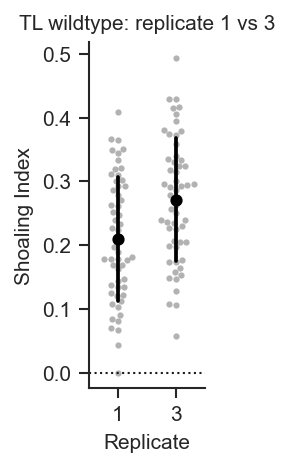

In [21]:
# Compare cohorts 1 vs 3 for TL wt genotype in the same style as the selection history plot.
cohort_compare = filtered_dfEpiAn[
    (filtered_dfEpiAn['bg'] == 'TL')
    & (filtered_dfEpiAn['cohort'].isin(['1', '3']))
    & (filtered_dfEpiAn['genotype'] == 'wt')
].copy()

# Optional: keep a single episode for consistency with earlier plots.
cohort_compare = cohort_compare[cohort_compare['episode'] == '02k20f']

# Put cohort on the x-axis and keep a stable order.
cohort_order = sorted(cohort_compare['cohort'].unique())

fig, axes = plt.subplots(figsize=(1, 3))
sns.swarmplot(
    data=cohort_compare,
    x='cohort',
    y='si',
    order=cohort_order,
    color='gray',
    size=3,
    alpha=.6,
    zorder=-1
 )
sns.pointplot(
    data=cohort_compare,
    x='cohort',
    y='si',
    order=cohort_order,
    color='black',
    errorbar='sd',
    linestyle='none'
 )
sns.despine()
axes.set_xlabel('Replicate')
axes.set_ylabel('Shoaling Index')
axes.axhline(0, ls=':', color='k')
plt.title('TL wildtype: replicate 1 vs 3');

## Selection history plotting helper


In [22]:
def plot_selection_history(dfEpiAn, episode=None, bg=None, cohort=None, selected=None, splitSetup=False, figsize=(5, 3), forceLabel=None):
    fig, axes = plt.subplots(figsize=figsize)

    ix = pd.Series([True] * len(dfEpiAn), index=dfEpiAn.index)
    if episode is not None:
        ix &= (dfEpiAn.episode == episode)
    if bg is not None:
        ix &= (dfEpiAn.bg == bg)
    if cohort is not None:
        ix &= (dfEpiAn.cohort == cohort)
    if selected is not None:
        ix &= (dfEpiAn.selected == selected)

    if forceLabel is not None:
        lineTxt = forceLabel
    else:
        lineTxt = f"{bg}{cohort}" if bg is not None and cohort is not None else ""

    selDat = dfEpiAn[ix]

    # if splitSetup: lineSet will be concatenated with setup to create a unique identifier for plotting.
    if splitSetup:
        selDat = selDat.copy()
        selDat['lineSet'] = selDat['lineSet'].astype(str) + '_' + selDat['setup'].astype(str)

    # Order by date first to keep newest experiments on the right.
    selDat = selDat.copy()
    selDat['_date_sort'] = pd.to_datetime(selDat['date'], errors='coerce')
    order = selDat.sort_values(['_date_sort', 'lineSet'])['lineSet'].unique().tolist()

    sns.swarmplot(
        data=selDat,
        x='lineSet',
        y='si',
        hue='genotype',
        order=order,
        zorder=-1,
        dodge=.5,
        size=2,
        alpha=.5,
        palette={'hi': '#FF8000', 'lo': '#0072B2', 'mid': '#009E73', 'wt': 'gray', 'esc': 'brown', 'cross': 'purple'},
        hue_order=["hi", "lo", 'mid', 'wt','esc','cross']
    )

    sns.pointplot(
        data=selDat,
        x='lineSet',
        y='si',
        order=order,
        hue='genotype',
        dodge=.5,
        linestyle='-',
        errorbar='sd',
        palette={'hi': '#FF8000', 'lo': '#0072B2', 'mid': '#009E73', 'wt': 'gray', 'esc': 'brown', 'cross': 'purple'},
        hue_order=["hi", "lo", 'mid', 'wt','esc','cross']
    )

    sns.despine()
    axes.set_ylabel('Shoaling Index')
    axes.set_xlabel('Cohort')
    axes.set_ylim(-0.1, 0.75)
    axes.axhline(0, ls=':', color='k')
    plt.xticks(rotation=90)

    handles, labels = axes.get_legend_handles_labels()
    plt.legend(
        handles[:5], labels[:5], title='Parents', ncol=1, handletextpad=0,
        bbox_to_anchor=(1, 1.05), frameon=False
    )
    plt.title('Shoaling selection history ' + lineTxt)
    return fig, axes


## TL cohort 1 selection history


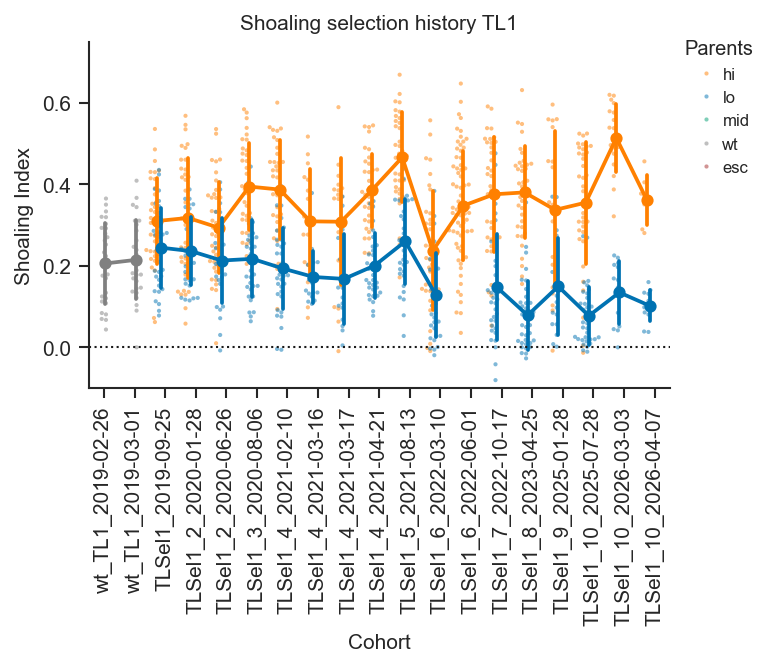

In [23]:
#Filter used to removed incomplete data points for poster presentation of Genopode 2025 retreat. 
plot_selection_history(filtered_dfEpiAn, episode='02k20f', bg='TL', cohort='1'); 

#Use this to plot the same data as Johannes did on the original notebook
#plot_selection_history(dfEpiAn, episode='02k20f', bg='TL', cohort='1', selected=1);

### TL cohort 1 selected animals


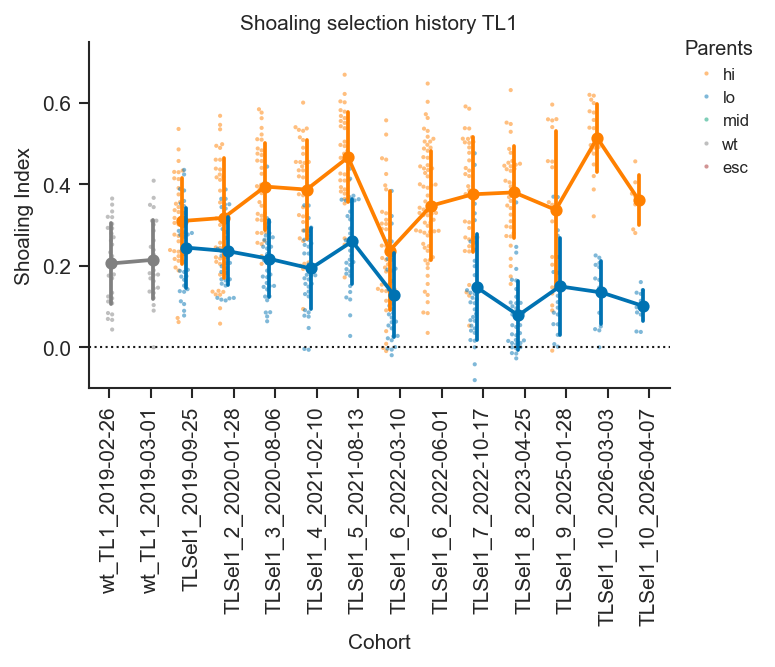

In [24]:
#Filter used to removed incomplete data points for poster presentation of Genopode 2025 retreat. 
plot_selection_history(filtered_dfEpiAn, episode='02k20f', bg='TL', cohort='1', selected=1); 

#Use this to plot the same data as Johannes did on the original notebook
#plot_selection_history(dfEpiAn, episode='02k20f', bg='TL', cohort='1', selected=1);

### TL cohort 1 pooled lines


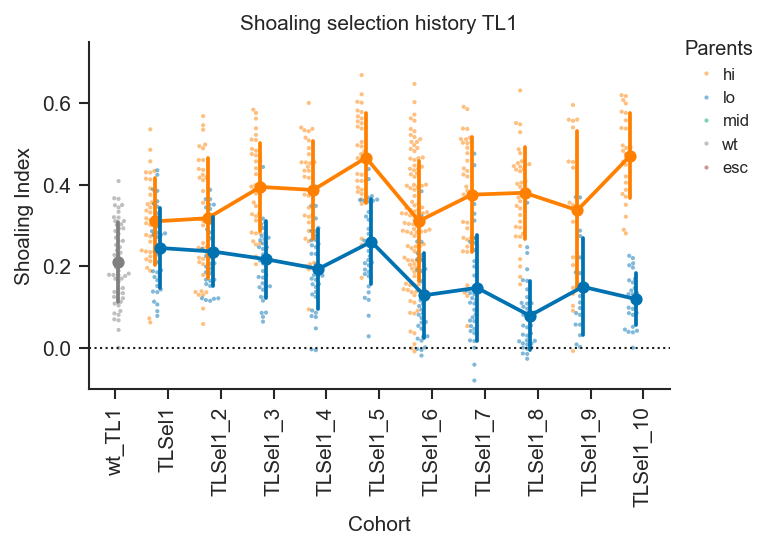

In [25]:
# Pool across experiments (episodes) for the same bg/cohort while keeping parents grouping.
# Keep the same episode as the previous plot to avoid extra points from other episodes.
pooled = filtered_dfEpiAn[
    (filtered_dfEpiAn.bg == 'TL')
    & (filtered_dfEpiAn.cohort == '1')
    & (filtered_dfEpiAn.episode == '02k20f')
].copy()
pooled['lineSet'] = pooled['line']
plot_selection_history(pooled, bg='TL', cohort='1', episode='02k20f', selected=1 );

### TL cohort 1 pooled lines up to target generation


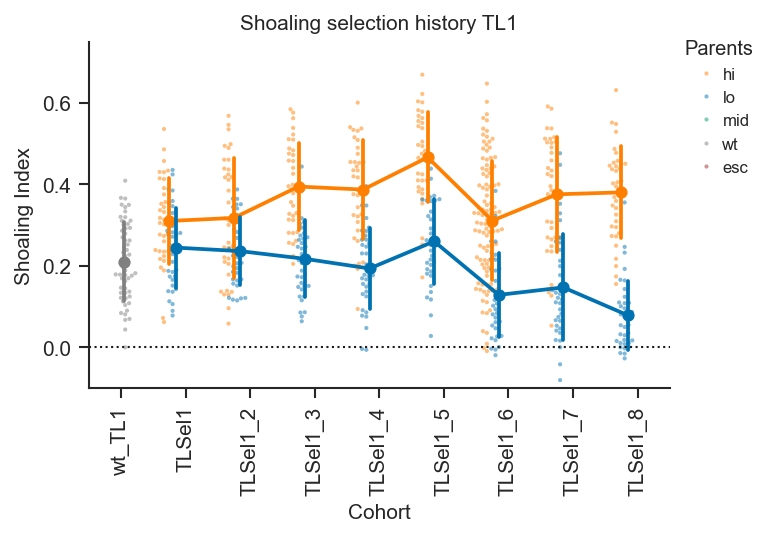

In [26]:
# Pool across experiments (episodes) for TL cohort 1, then keep lines up to TLSel1_8.
pooled_until = filtered_dfEpiAn[
    (filtered_dfEpiAn.bg == 'TL')
    & (filtered_dfEpiAn.cohort == '1')
    & (filtered_dfEpiAn.episode == '02k20f')
] .copy()
pooled_until['lineSet'] = pooled_until['line']

target_line = 'TLSel1_8'
ordered_lines = (
    pooled_until
    .assign(_date_sort=pd.to_datetime(pooled_until['date'], errors='coerce'))
    .sort_values(['_date_sort', 'lineSet'])['lineSet']
    .unique()
    .tolist()
 )
if target_line in ordered_lines:
    cutoff_index = ordered_lines.index(target_line) + 1
    keep_lines = ordered_lines[:cutoff_index]
else:
    keep_lines = ordered_lines
    print(f"WARNING: {target_line} not found. Plotting all available lines.")

pooled_until = pooled_until[pooled_until['lineSet'].isin(keep_lines)]
plot_selection_history(
    pooled_until, bg='TL', cohort='1', episode='02k20f', selected=1,
    #forceLabel='TL1'
 );

## TL cohort 3 selection history


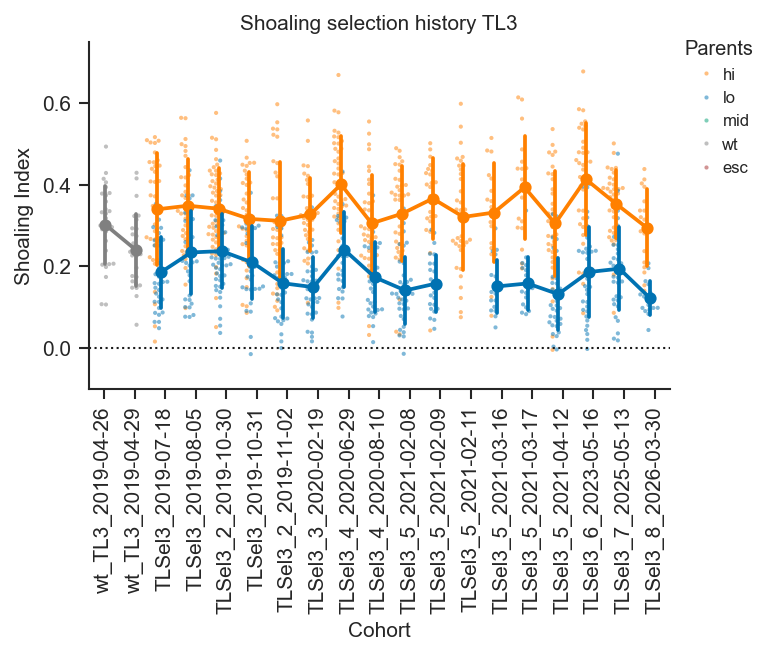

In [27]:
#Filter used to removed incomplete data points for poster presentation of Genopode 2025 retreat. 
plot_selection_history(filtered_dfEpiAn, episode='02k20f', bg='TL', cohort='3'); 

#Use this to plot the same data as Johannes did on the original notebook
#plot_selection_history(dfEpiAn, episode='02k20f', bg='TL', cohort='3', selected=1);

### TL cohort 3 selected animals


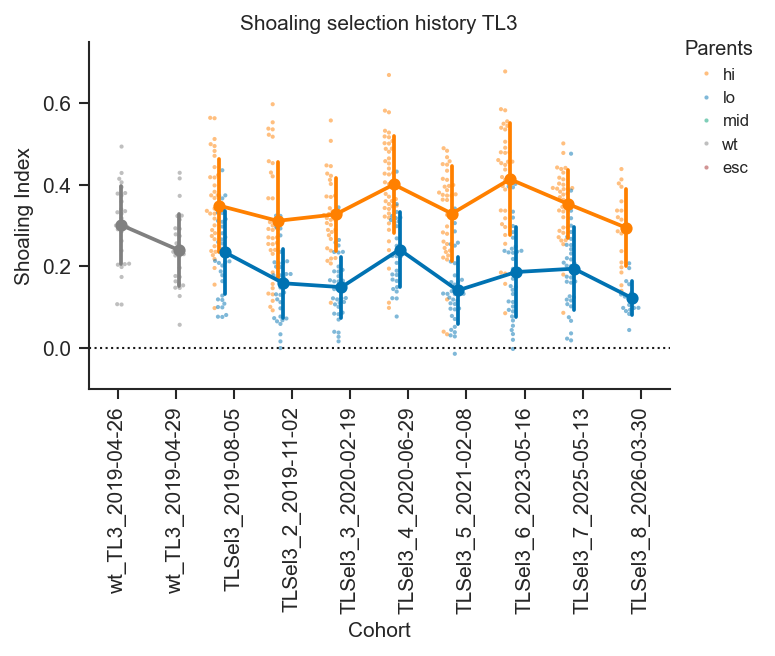

In [28]:
#Filter used to removed incomplete data points for poster presentation of Genopode 2025 retreat. 
plot_selection_history(filtered_dfEpiAn, episode='02k20f', bg='TL', cohort='3', selected=1); 

#Use this to plot the same data as Johannes did on the original notebook
#plot_selection_history(dfEpiAn, episode='02k20f', bg='TL', cohort='3', selected=1);

### TL cohort 3 pooled lines


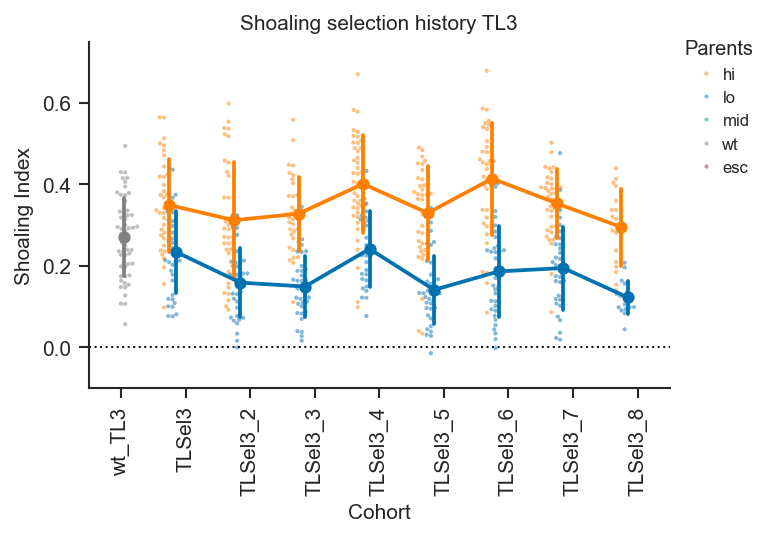

In [29]:
# Pool across experiments (episodes) for the same bg/cohort while keeping parents grouping.
# Keep the same episode as the previous plot to avoid extra points from other episodes.
pooled = filtered_dfEpiAn[
    (filtered_dfEpiAn.bg == 'TL')
    & (filtered_dfEpiAn.cohort == '3')
    & (filtered_dfEpiAn.episode == '02k20f')
].copy()
pooled['lineSet'] = pooled['line']
plot_selection_history(pooled, bg='TL', cohort='3', episode='02k20f', selected=1);

### TL cohort 3 pooled lines up to target generation


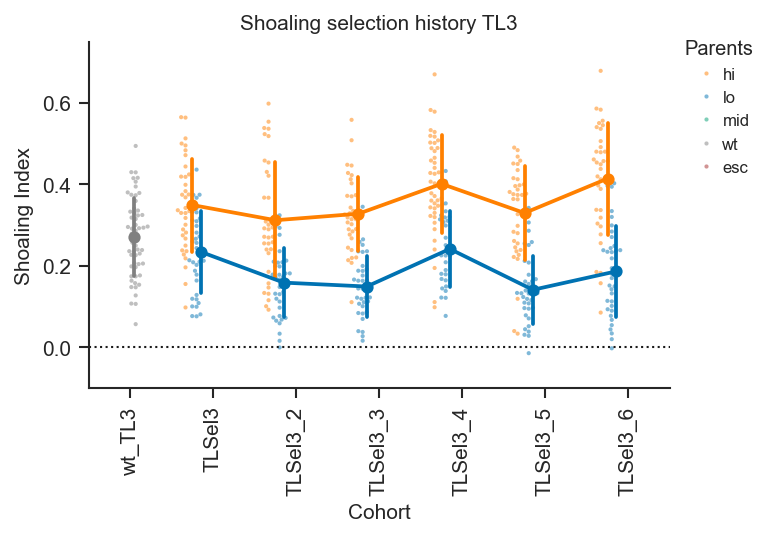

In [30]:
# Pool across experiments (episodes) for TL cohort 1, then keep lines up to TLSel1_8.
pooled_until = filtered_dfEpiAn[
    (filtered_dfEpiAn.bg == 'TL')
    & (filtered_dfEpiAn.cohort == '3')
    & (filtered_dfEpiAn.episode == '02k20f')
] .copy()
pooled_until['lineSet'] = pooled_until['line']

target_line = 'TLSel3_6'
ordered_lines = (
    pooled_until
    .assign(_date_sort=pd.to_datetime(pooled_until['date'], errors='coerce'))
    .sort_values(['_date_sort', 'lineSet'])['lineSet']
    .unique()
    .tolist()
 )
if target_line in ordered_lines:
    cutoff_index = ordered_lines.index(target_line) + 1
    keep_lines = ordered_lines[:cutoff_index]
else:
    keep_lines = ordered_lines
    print(f"WARNING: {target_line} not found. Plotting all available lines.")

pooled_until = pooled_until[pooled_until['lineSet'].isin(keep_lines)]
plot_selection_history(
    pooled_until, bg='TL', cohort='3', episode='02k20f', selected=1,
    #forceLabel='TL3'
 );

## GC cohort selection history


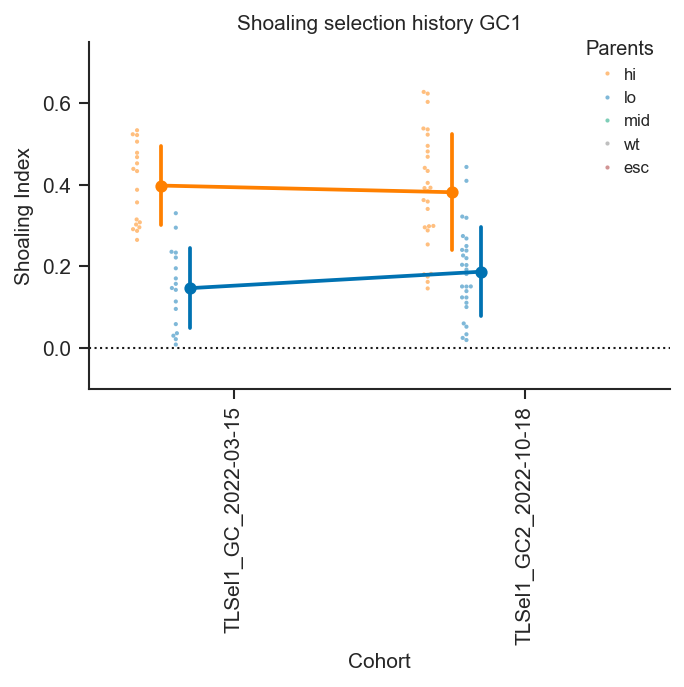

In [31]:
#Filter used to removed incomplete data points for poster presentation of Genopode 2025 retreat. 
#plot_selection_history(filtered_dfEpiAn, episode='02k20f', bg='GC', cohort='1', selected=1); 

#Use this to plot the same data as Johannes did on the original notebook
plot_selection_history(dfEpiAn, episode='02k20f', bg='GC', cohort='1', selected=1);

## RNA-seq selection history subset


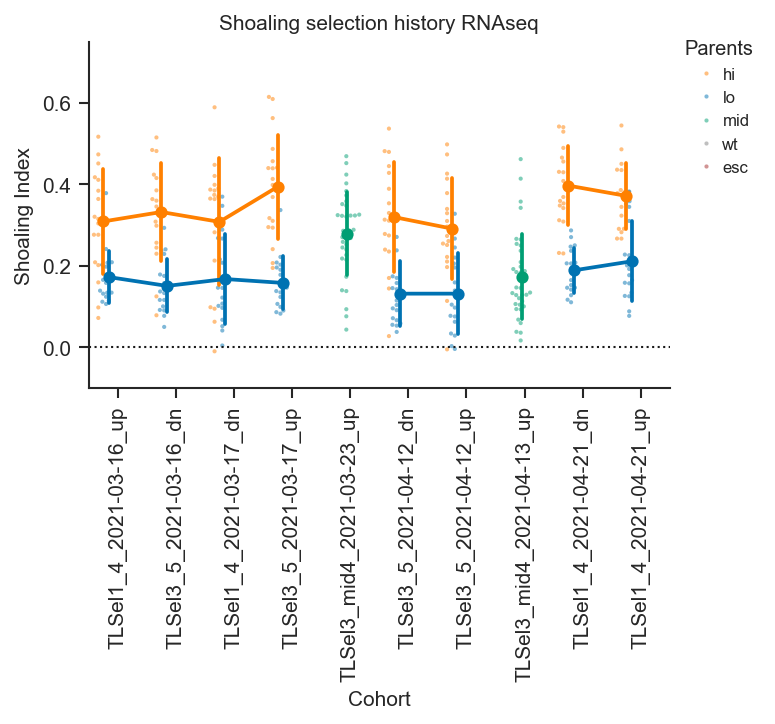

In [32]:
subset=dfEpiAn[dfEpiAn.rnaSet.isin(['a','b','c','d'])]
plot_selection_history(subset, 
                       episode='02k20f', 
                       bg='TL', 
                       selected=0, 
                       splitSetup=True,
                       forceLabel='RNAseq');